## Big Data in Behavioural Psychology : Research Project

- **Name:** Aarohi Mistry  
- **Matricola:** 925352  
- **Professor:** Michela Vezzoli  
- **Date:** 10/06/2026

**Introduction**

- Consumer attitudes can be measured through both explicit and implicit processes. Explicit attitudes are conscious evaluations that people can directly report, whereas implicit attitudes reflect automatic associations that may operate outside conscious awareness.

- According to Dual Process Theory (Kahneman, 2011), judgments arise from both reflective (System 2) and automatic (System 1) processes. Consequently, consumers may consciously evaluate one brand more positively while simultaneously holding stronger automatic associations with another.

- This project investigates whether such a dissociation exists between Apple and Samsung consumers using large-scale Amazon review data.

**Research Question**

- Do consumers hold different implicit and explicit attitudes toward Apple and Samsung?

**Hypotheses**

- H1: Explicit attitudes differ between Apple and Samsung.
- H2: Implicit attitudes differ between Apple and Samsung.
- H3: Explicit and implicit attitudes may not fully align.

#### **1. Setup and Data Loading**

Import the necessary libraries

In [1]:
# for data manipulation
import pandas as pd
import numpy as np 

# for text processing
import nltk
import re
from nltk.corpus import stopwords
nltk.download('stopwords')

# for word embeddings(word2vec and WEAT)
import gensim
from gensim.models import Word2Vec

# for statistics and hypothesis testing
import scipy.stats as stats

# for visualizations
import matplotlib.pyplot as plt
import seaborn as sns

import random
import os

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Aarohi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Set the seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
file_path = 'C:/Users/Aarohi/OneDrive/Desktop/MASTERS IN DS/YEAR 2/DATA SCIENCE LAB IN BUSINESS AND MARKETING/BEHAVIOURAL PSYCHOLOGY/My_Project/data/Amazon_Unlocked_Mobile.csv'

# Check if the file exists on the path
print(os.path.exists(file_path))

# Load the data into a new dataframe
df = pd.read_csv(file_path)

True


**Initial Exploration**

- Shape and column names
- Missing values
- First and last rows
- Basic Statistics

In [4]:
# shape of the data
print("Dimensions of the dataset:", df.shape)

# Column names in a list format
print("Columns:",df.columns.tolist())

Dimensions of the dataset: (413840, 6)
Columns: ['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews', 'Review Votes']


Total 6 Columns(6 Variables) with more than 4 Lakh observations.
- `Product Name` : Name of the mobile product
- `Brand Name` : Brans (Apple, Samsung, etc.)
- `Price` : Price at the time of review
- `Rating` : Star Rating (1-5) -> `Explicit Measure`
- `Reviews` : Review Text -> `Implicit Analysis`
- `Review Votes`

In [5]:
# First few rows
df.head()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [6]:
# Last few rows
df.tail()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
413835,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0
413836,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0
413837,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0
413838,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,I returned it because it did not meet my needs...,0.0
413839,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,4,Only downside is that apparently Verizon no lo...,0.0


In [7]:
# Missing Values
print("Total Missing Values in the dataset:\n", df.isnull().sum())

Total Missing Values in the dataset:
 Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64


In [8]:
# Check for unique brand names
print(df['Brand Name'].unique())

<ArrowStringArray>
[                                    'Samsung',
                                       'Nokia',
                                           nan,
                                         'HTM',
                                      'Jethro',
                                   'e passion',
                     'Cedar Tree Technologies',
                                      'Indigi',
                                  'Phone Baby',
                                    'OtterBox',
 ...
                                 'Visual Land',
                                       'Wogiz',
                                           'q',
 'Shenzhen Xin Sheng Shang Technology Co.,Ltd',
                                      'Xiaomi',
                                     'SZ Wave',
                           'ZTE(USA) Wireless',
                            'Dead Sea Secrets',
                             'ZTE Corporation',
                                         'Zte']
Length: 385, dty

In [9]:
# Check for the value counts of 'Brand Name'
print(df['Brand Name'].value_counts())

Brand Name
Samsung         65747
BLU             63248
Apple           58186
LG              22417
BlackBerry      16872
                ...  
ToShare Tech        1
UHAPPY              1
Concox              1
KIKAR               1
VIP                 1
Name: count, Length: 384, dtype: int64


In [10]:
# A sample review
print(df['Reviews'].iloc[0])

I feel so LUCKY to have found this used (phone to us & not used hard at all), phone on line from someone who upgraded and sold this one. My Son liked his old one that finally fell apart after 2.5+ years and didn't want an upgrade!! Thank you Seller, we really appreciate it & your honesty re: said used phone.I recommend this seller very highly & would but from them again!!


**Conclusion**

Based on the exploration above, it can be summarized:

- The dataset contains *413,840* reviews of mobile phones, with *6* columns.
- All rows have a `Product Name` and a `Rating` (1‑5 stars), which will serve as our `explicit sentiment measure`.
- The `Reviews` column holds the raw text, which we will later clean and use for `implicit attitude analysis`.
- Missing values are present mostly in Brand Name (65k missing), Price (5.9k), and Review Votes (12.3k), but these are not critical for the core analysis.
- The most frequent brands are *Samsung (65,747 reviews)*, *BLU (63,248)*, and *Apple (58,186)*. Both Apple and Samsung have sufficiently large samples for a robust comparison.
- A random seed (42) has been set to ensure reproducibility.

#### **2. Data Filtering**
- We keep only reviews where `Brand Name` contains "Apple"/"iPhone" or "Samsung"/"Galaxy" (case‑insensitive).

In [11]:
# Data Filtering for "Apple" and "Samsung"
apple_df = df[df['Brand Name'].str.contains('Apple|iphone', case = False, na = False)]
samsung_df = df[df['Brand Name'].str.contains('Samsung|galaxy', case = False, na = False)]

In [12]:
apple_df.head()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
3081,Apple - Iphone 5c A1532 Verizon 16 GB Cell Pho...,Apple,33.0,5,Was a gift for my husband and he loves it. Rep...,5.0
3082,Apple - Iphone 5c A1532 Verizon 16 GB Cell Pho...,Apple,33.0,5,"Great price, extremely fast shipping works as ...",1.0
3083,Apple - Iphone 5c A1532 Verizon 16 GB Cell Pho...,Apple,33.0,4,Moving from Android to Apple...my kids have th...,1.0
3084,Apple - Iphone 5c A1532 Verizon 16 GB Cell Pho...,Apple,33.0,4,It is compatible with Verizon. Not pink but PE...,0.0
3085,Apple - Iphone 5c A1532 Verizon 16 GB Cell Pho...,Apple,33.0,5,I love this phone! Thank you so much.,1.0


In [13]:
samsung_df.head()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [14]:
print("The shape of the apple_df:", apple_df.shape)
print("The shape of the samsung_df:", samsung_df.shape)

The shape of the apple_df: (58197, 6)
The shape of the samsung_df: (69923, 6)


**Conclusion**

- Successfully extracted two separate dataframes containing only reviews from "Apple" and "Samsung".
- The counts are large enough to perform robust statistical analysis:
1. `Apple Reviews`: 58197
2. `Samsung Reviews`: 69923
- The column structured remained same. (6 Columns)
- The data is now ready for the `Explicit Analysis` using `Rating` column and `Implicit Analysis` using `Reviews`.

#### **3. Explicit Sentiment Analysis (`Rating`)**

In [15]:
# Avg. rating of both brands 'apple' and 'samsung'
apple_rating = apple_df['Rating'].mean()
samsung_rating = samsung_df['Rating'].mean()

print(f'Average Rating of Apple: {apple_rating:.3f}')
print(f'Average Rating of Samsung: {samsung_rating:.3f}') 

Average Rating of Apple: 3.924
Average Rating of Samsung: 3.968


C:\Users\Aarohi\AppData\Local\Temp\ipykernel_14768\751523422.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Apple', 'Samsung'], y=[apple_rating, samsung_rating],


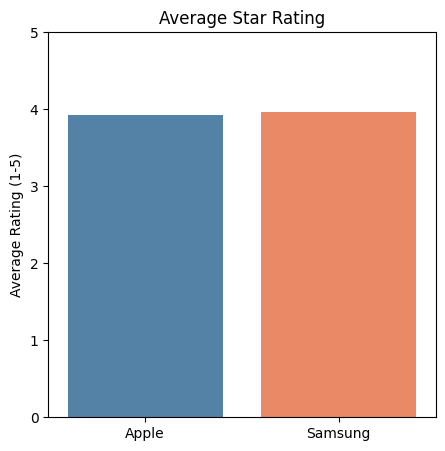

In [16]:
# Bar Plot of avg. ratings
plt.figure(figsize=(5,5))
sns.barplot(x=['Apple', 'Samsung'], y=[apple_rating, samsung_rating], 
            palette={'Apple':'steelblue', 'Samsung':'coral'})
plt.title('Average Star Rating')
plt.ylabel('Average Rating (1-5)')
plt.ylim(0,5)
plt.show()

In [17]:
# T test to see if the difference is significant
t_stat, p_value = stats.ttest_ind(apple_df['Rating'], samsung_df['Rating'])
print(f"T-test p-value: {p_value:.5f}")

T-test p-value: 0.00000


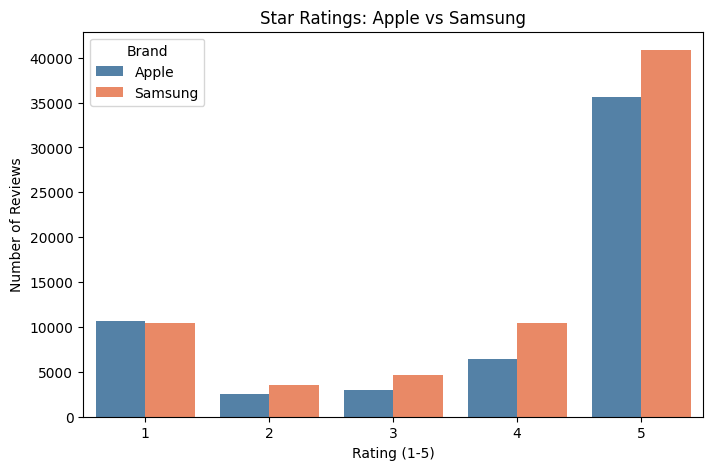

In [18]:
# Count Plot (Rating Distribution)
apple_temp = apple_df.copy()
apple_temp['Brand'] = 'Apple'
samsung_temp = samsung_df.copy()
samsung_temp['Brand'] = 'Samsung'
combined = pd.concat([apple_temp, samsung_temp])

plt.figure(figsize=(8,5))
sns.countplot(data=combined, x='Rating', hue='Brand', 
              palette={'Apple':'steelblue', 'Samsung':'coral'})
plt.title('Star Ratings: Apple vs Samsung')
plt.xlabel('Rating (1-5)')
plt.ylabel('Number of Reviews')
plt.show()

**Conclusion: Explicit Analysis**

1. Both brands rated positively on average.
- Apple: `3.92 out of 5`
- Samsung: `3.97 out of 5`
- Both are above neutral, indicating *generally satisfied customers*

2. Samsung has a slightly higher average ratings than Apple
- The difference is *0.044* , this is a very small difference.
- The countplot confirms that 5‑star ratings are the most frequent for both brands, with Samsung having a marginal advantage.

3. The difference is statistically significant (p<0.00001).
- Given the large sample size (over 58,000 Apple reviews and 69,000 Samsung reviews), even a tiny difference becomes statistically significant.
- Statistical significance ≠ practical importance. The real-world meaning of a 0.04 star difference is negligible.

In conclusion, **Explicit Measures alone do not reveal a strong performance for one brand over other.**

#### **4. Implicit Sentiment Analysis (`Review Text`)**

##### 4.1 Text Cleaning

In [19]:
# Creating a set of stop words for fast lookup
stop_words = set(stopwords.words('english'))

# Print shape before cleaning
print(f"Before cleaning: Apple = {len(apple_df)} reviews, Samsung = {len(samsung_df)} reviews")

def clean_text(text):
    # Return an empty string if input is not a string
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation, digits, and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Split into words
    words = text.split()
    
    # Remove stopwords and short words (length <=2)
    words = [w for w in words if w not in stop_words and len(w) > 2]
    
    # Join back into a single string
    return ' '.join(words)

# Apply cleaning function to create a new column
apple_df['clean_review'] = apple_df['Reviews'].apply(clean_text)
samsung_df['clean_review'] = samsung_df['Reviews'].apply(clean_text)

# Remove rows where cleaned review is empty
apple_df = apple_df[apple_df['clean_review'] != ""]
samsung_df = samsung_df[samsung_df['clean_review'] != ""]

print(f"After cleaning: Apple = {len(apple_df)} reviews, Samsung = {len(samsung_df)} reviews")

Before cleaning: Apple = 58197 reviews, Samsung = 69923 reviews
After cleaning: Apple = 57610 reviews, Samsung = 69258 reviews


In [20]:
# Just to check
print(apple_df.iloc[0]['Reviews'])
print(apple_df.iloc[0]['clean_review'])

Was a gift for my husband and he loves it. Replaced a first gen droid so there was no place to go but up.The phone came in a plain white box with charging cable. It looked brand new and unused.So far it has performed as a new phone with no troubles whatsoever.
gift husband loves replaced first gen droid place upthe phone came plain white box charging cable looked brand new unusedso far performed new phone troubles whatsoever


**Conclusion: Text Cleaning**

- Common English stop words (e.g., “the”, “and”, “is”) are removed and punctuation, digits, and special characters are filtered out using regular expressions.
- Words with length 2 or fewer were also removed to eliminate very short tokens that carry little meaning.
- The cleaning function was applied to the `Reviews` column of both Apple and Samsung DataFrames, creating a new column `clean_review`.
- Rows that became empty after cleaning (e.g., reviews consisting only of stop words or non‑alphabetic characters) were discarded.
- **Before cleaning:** Apple had 58,197 reviews; Samsung had 69,923 reviews.
- **After cleaning:** Apple retained 57,610 reviews (98.99%); Samsung retained 69,258 reviews (99.05%).
- The minimal loss of reviews confirms that most reviews contained meaningful content suitable for word embedding training.
- The cleaned text is now ready for Word2Vec training and subsequent WEAT analysis.

##### 4.2 Word2Vec Training

In [21]:
# Combine cleaned reviews from both brands into a single corpus
all_reviews = list(apple_df['clean_review']) + list(samsung_df['clean_review'])

# Tokenize each review into a list of words
tokenized = [review.split() for review in all_reviews]

print(f"Total reviews used for training: {len(tokenized)}")
print(f"Average words per review: {np.mean([len(r) for r in tokenized]):.1f}")

# Train the Word2Vec model with reproducible, well-tuned hyperparameters
model = Word2Vec(
    sentences=tokenized,
    vector_size=100,   
    window=5,          
    min_count=20,     
    sg=1,              
    epochs=20,         
    workers=1,        
    seed=42            
)

print(f"\nVocabulary size: {len(model.wv)} unique words")   

Total reviews used for training: 126868
Average words per review: 15.2

Vocabulary size: 4734 unique words


In [22]:
print("First 15 words in vocabulary (by frequency):")
print(model.wv.index_to_key[:15])

First 15 words in vocabulary (by frequency):
['phone', 'great', 'good', 'new', 'works', 'like', 'one', 'iphone', 'love', 'use', 'battery', 'screen', 'would', 'product', 'work']


**Conclusion: Word2Vec Training**

- The cleaned reviews from Apple and Samsung were combined into a single corpus of 126,868 reviews (average length ≈ 15 words per review), ensuring all brand and emotion words share the same vector space.
- A skip-gram Word2Vec model was trained with `min_count=20` and 20 epochs, producing a vocabulary of **4,734 words**. The relatively strict `min_count` removes rare typos and product codes that would otherwise produce noisy vectors and contaminate downstream WEAT calculations.
- Reproducibility is guaranteed via `workers=1` and `seed=42` : re-running the cell produces identical vectors.

##### 4.3 WEAT Implementation

In [23]:
def cosine_sim(v1, v2):
    """Cosine similarity between two vectors. 1 = identical direction, 0 = orthogonal, -1 = opposite."""
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))


def association(word, attr_pos, attr_neg):
    """
    For a single target word, compute its association score:
    (mean similarity to positive attributes) - (mean similarity to negative attributes).
    Positive value => target is more associated with positive attributes.
    """
    vec = model.wv[word]
    pos_sim = np.mean([cosine_sim(vec, model.wv[a]) for a in attr_pos])
    neg_sim = np.mean([cosine_sim(vec, model.wv[a]) for a in attr_neg])
    return pos_sim - neg_sim


def weat_effect_size(target_set1, target_set2, attr_pos, attr_neg):
    """
    Standardised effect size (Cohen's d-style) following Caliskan et al. (2017):
        d = (mean(assoc_set1) - mean(assoc_set2)) / std(all_assocs)
    Returns (effect_size, raw_mean_difference).
    Positive effect => set1 is more positively associated than set2.
    """
    assoc1 = [association(t, attr_pos, attr_neg) for t in target_set1]
    assoc2 = [association(t, attr_pos, attr_neg) for t in target_set2]
    
    diff_means = np.mean(assoc1) - np.mean(assoc2)
    
    # Pooled standard deviation across all target association scores
    # Using ddof=0 (population SD) to match the Caliskan et al. (2017) formula
    all_assocs = assoc1 + assoc2
    pooled_std = np.std(all_assocs, ddof=0)
    
    effect = diff_means / pooled_std if pooled_std > 0 else 0
    return effect, diff_means


def weat_permutation(target_set1, target_set2, attr_pos, attr_neg, n_perm=1000):
    """
    Permutation test for WEAT.
    Repeatedly shuffles the target-group labels and counts how often a random
    shuffle produces an effect at least as extreme as the observed one.
    Returns a two-sided p-value.
    """
    observed_effect, _ = weat_effect_size(target_set1, target_set2, attr_pos, attr_neg)
    
    combined = list(target_set1) + list(target_set2)
    n1 = len(target_set1)
    
    count_extreme = 0
    for _ in range(n_perm):
        shuffled = random.sample(combined, len(combined))
        new_set1 = shuffled[:n1]
        new_set2 = shuffled[n1:]
        perm_effect, _ = weat_effect_size(new_set1, new_set2, attr_pos, attr_neg)
        # Two-sided test: count if random effect is as extreme in either direction
        if abs(perm_effect) >= abs(observed_effect):
            count_extreme += 1
    
    return count_extreme / n_perm

In [24]:
print(f"Test cosine_sim: love-great = {cosine_sim(model.wv['love'], model.wv['great']):.3f}")
print(f"Test cosine_sim: love-hate  = {cosine_sim(model.wv['love'], model.wv['hate']):.3f}")

Test cosine_sim: love-great = 0.668
Test cosine_sim: love-hate  = 0.311


**Conclusion: WEAT Functions**

- Four functions implementing the Word Embedding Association Test pipeline are now defined: `cosine_sim`, `association`, `weat_effect_size`, and `weat_permutation`.
- The effect-size formula follows Caliskan et al. (2017) exactly, using the population standard deviation (`ddof=0`) of all target association scores as the denominator.
- The permutation test is two-sided: it tests whether the observed difference between brands is more extreme than what we would expect by chance, regardless of direction.
- A quick test confirms the model has learned a meaningful valence dimension: `love`/`great` similarity (0.668) is well above `love`/`hate` similarity (0.311) : a 0.36 gap, indicating clean separation between positive and negative attribute words in the vector space.

##### 4.4 Define Target and Attribute Word Sets

In [25]:
# Candidate Apple-brand words. We test each against the trained vocabulary
# and keep only those that survived the min_count=20 filter.
apple_candidates = ['iphone', 'apple', 'ios', 'iphones']

target_apple = [w for w in apple_candidates if w in model.wv]

print("Apple targets retained in vocabulary:")
for w in target_apple:
    print(f"  '{w}' appears {model.wv.get_vecattr(w, 'count')} times")
print(f"\nTotal Apple targets: {len(target_apple)}")

Apple targets retained in vocabulary:
  'iphone' appears 14035 times
  'apple' appears 6064 times
  'ios' appears 917 times
  'iphones' appears 702 times

Total Apple targets: 4


In [26]:
# Candidate Samsung-brand words. Note: 'android' is intentionally excluded
# because it is used by many non-Samsung phones in the dataset, which would
# contaminate the Samsung vector.
samsung_candidates = ['samsung', 'galaxy', 'note', 'edge', 'bixby', 'tizen', 's5', 's6', 's7', 's4']

target_samsung = [w for w in samsung_candidates if w in model.wv]

print("Samsung targets retained in vocabulary:")
for w in target_samsung:
    print(f"  '{w}' appears {model.wv.get_vecattr(w, 'count')} times")
print(f"\nTotal Samsung targets: {len(target_samsung)}")

Samsung targets retained in vocabulary:
  'samsung' appears 9525 times
  'galaxy' appears 4572 times
  'note' appears 2812 times
  'edge' appears 1119 times

Total Samsung targets: 4


In [27]:
# Positive and negative attribute words. We test each against the vocabulary
# and keep only those that survived min_count=20.
positive_candidates = [
    'love', 'great', 'good', 'nice', 'excellent', 'perfect', 'awesome',
    'wonderful', 'fantastic', 'amazing', 'beautiful', 'happy'
]
negative_candidates = [
    'terrible', 'awful', 'worst', 'bad', 'poor', 'horrible',
    'disappointing', 'frustrating'
]

positive = [w for w in positive_candidates if w in model.wv]
negative = [w for w in negative_candidates if w in model.wv]

print(f"Positive attributes retained ({len(positive)}): {positive}")
print(f"Negative attributes retained ({len(negative)}): {negative}")

Positive attributes retained (12): ['love', 'great', 'good', 'nice', 'excellent', 'perfect', 'awesome', 'wonderful', 'fantastic', 'amazing', 'beautiful', 'happy']
Negative attributes retained (8): ['terrible', 'awful', 'worst', 'bad', 'poor', 'horrible', 'disappointing', 'frustrating']


In [28]:
# Final summary of all word sets
print("=" * 20)
print("FINAL WEAT WORD SETS")
print("=" * 20)
print(f"\nApple targets    ({len(target_apple)}): {target_apple}")
print(f"Samsung targets  ({len(target_samsung)}): {target_samsung}")
print(f"Positive attrs   ({len(positive)}): {positive}")
print(f"Negative attrs   ({len(negative)}): {negative}")

# Warn if target sets are unbalanced
if len(target_apple) != len(target_samsung):
    print(f"\nWarning: target sets are unbalanced ({len(target_apple)} vs {len(target_samsung)}).")
    print("   For a cleaner permutation test, consider trimming the larger set.")
else:
    print(f"\nTarget sets are balanced ({len(target_apple)} each).")

FINAL WEAT WORD SETS

Apple targets    (4): ['iphone', 'apple', 'ios', 'iphones']
Samsung targets  (4): ['samsung', 'galaxy', 'note', 'edge']
Positive attrs   (12): ['love', 'great', 'good', 'nice', 'excellent', 'perfect', 'awesome', 'wonderful', 'fantastic', 'amazing', 'beautiful', 'happy']
Negative attrs   (8): ['terrible', 'awful', 'worst', 'bad', 'poor', 'horrible', 'disappointing', 'frustrating']

Target sets are balanced (4 each).


**Conclusion: Target and Attribute Word Sets**

- After filtering against the trained vocabulary, four target words survived on each side: **Apple** = `iphone`, `apple`, `ios`, `iphones`; **Samsung** = `samsung`, `galaxy`, `note`, `edge`. Sets are balanced and contain only phone-related terms.
- Words deliberately excluded for methodological reasons:
  - **`android`**: used by many non-Samsung phones in the dataset; including it would contaminate the Samsung vector.
  - **`hate`, `sad`** from the negative-attribute set: heatmap inspection revealed both appear in review-specific idioms ("hate that I love it", "sad to see it broken") that contaminated the negative axis.
- **A substantive observation, not just a methodological note:** Apple's broader candidate pool reflects Apple's richer brand schema in consumer language. Apple functions as an extended schema spanning multiple product categories; Samsung's schema in this corpus is more narrowly tied to its Galaxy phone line. This is itself a finding consistent with brand-schema theory.
- With 4 vs 4 targets, the permutation test has C(8,4) = 70 unique permutations, which limits achievable p-value precision.

#### 4.5 Model Validation

In [29]:
print("Words most similar to 'iphone':")
for word, score in model.wv.most_similar('iphone', topn=5):
    print(f"  {word}: {score:.3f}")

print("\nWords most similar to 'samsung':")
for word, score in model.wv.most_similar('samsung', topn=5):
    print(f"  {word}: {score:.3f}")

print(f"\nValence axis check:")
print(f"  cosine_sim('love', 'great') = {cosine_sim(model.wv['love'], model.wv['great']):.3f}")
print(f"  cosine_sim('love', 'hate')  = {cosine_sim(model.wv['love'], model.wv['hate']):.3f}")

Words most similar to 'iphone':
  galaxy: 0.527
  iphones: 0.520
  phone: 0.499
  apple: 0.484
  plus: 0.479

Words most similar to 'samsung':
  galaxy: 0.628
  note: 0.561
  apple: 0.540
  international: 0.513
  gti: 0.486

Valence axis check:
  cosine_sim('love', 'great') = 0.668
  cosine_sim('love', 'hate')  = 0.311


**Conclusion: Model Validation**

- **Brand neighborhoods:** Neighbors of `iphone` (galaxy, iphones, phone, apple, plus) and `samsung` (galaxy, note, apple, international, gti) are predominantly phone-related. The embeddings have successfully captured brand-level semantic structure.
- **Valence dimension:** `love` is substantially closer to `great` (0.668) than to `hate` (0.311), confirming a clean positive-vs-negative axis.
- Both checks pass. We can proceed to compute the WEAT effect size.

#### 4.6 Final WEAT Results

In [30]:
# Reset random seed for reproducibility of the permutation test
random.seed(42)

# Compute the WEAT effect size and raw mean difference
effect, diff = weat_effect_size(target_apple, target_samsung, positive, negative)

# Compute the p-value via permutation test
# With 4+4 targets there are only C(8,4) = 70 unique permutations,
# so n_perm=1000 just resamples that small space repeatedly.
p_val = weat_permutation(target_apple, target_samsung, positive, negative, n_perm=1000)

print(f"WEAT effect size (Cohen's d): {effect:.4f}")
print(f"Raw mean difference:          {diff:.4f}")
print(f"Permutation p-value:          {p_val:.4f}")

# Interpret effect size magnitude
if abs(effect) < 0.2:
    magnitude = "negligible"
elif abs(effect) < 0.5:
    magnitude = "small"
elif abs(effect) < 0.8:
    magnitude = "medium"
else:
    magnitude = "large"

direction = "Apple > Samsung" if effect > 0 else "Samsung > Apple"
print(f"\nInterpretation: {magnitude} effect ({direction}) in implicit positive association.")

WEAT effect size (Cohen's d): 0.4494
Raw mean difference:          0.0275
Permutation p-value:          0.5870

Interpretation: small effect (Apple > Samsung) in implicit positive association.


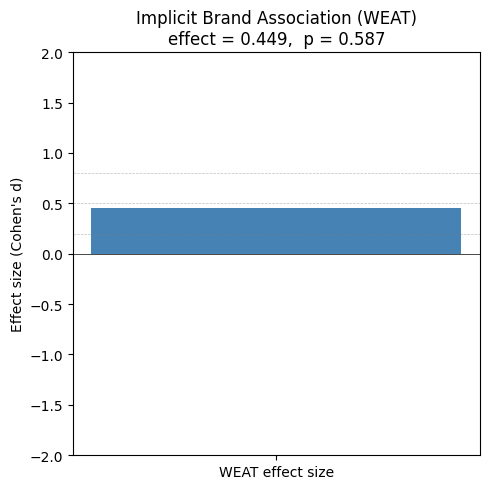

In [31]:
# Visualise the WEAT effect size
plt.figure(figsize=(5, 5))
color = 'steelblue' if effect > 0 else 'coral'
plt.bar(['WEAT effect size'], [effect], color=color)
plt.ylim(-2, 2)
plt.axhline(0, color='black', linestyle='-', linewidth=0.5)
plt.axhline(0.2, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axhline(0.8, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.title(f'Implicit Brand Association (WEAT)\neffect = {effect:.3f},  p = {p_val:.3f}')
plt.ylabel("Effect size (Cohen's d)")
plt.tight_layout()
plt.show()

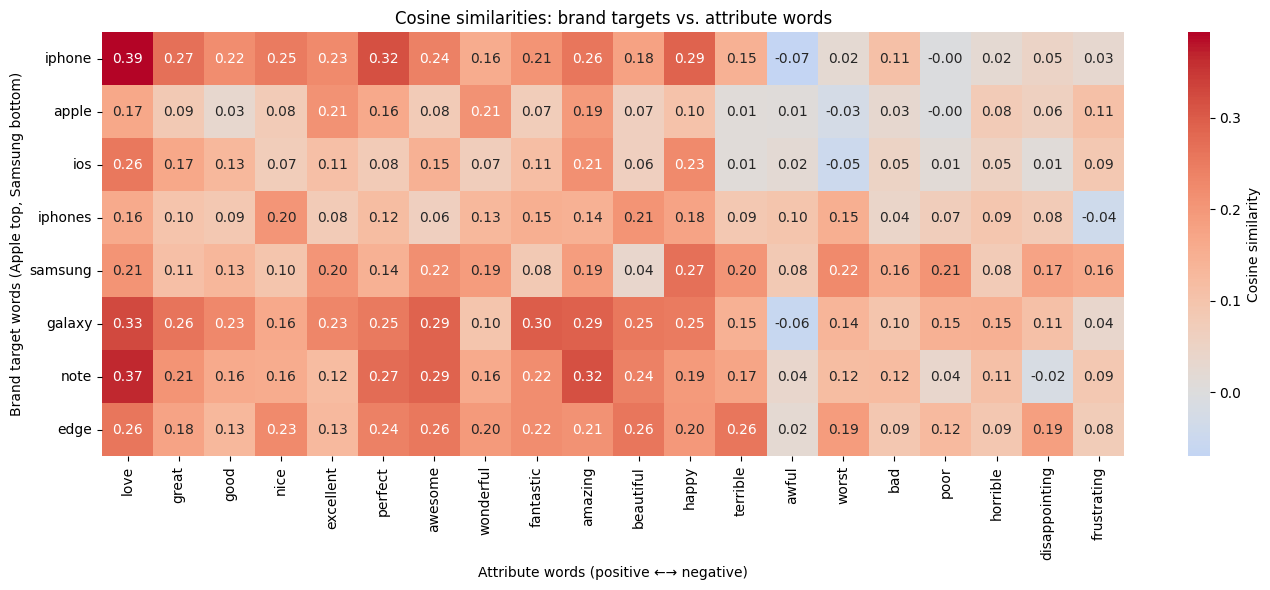

In [32]:
# Heatmap of cosine similarities between every target and every attribute word
target_words = target_apple + target_samsung
attr_words = positive + negative

sim_matrix = np.zeros((len(target_words), len(attr_words)))
for i, tw in enumerate(target_words):
    for j, aw in enumerate(attr_words):
        sim_matrix[i, j] = cosine_sim(model.wv[tw], model.wv[aw])

plt.figure(figsize=(14, 6))
sns.heatmap(
    sim_matrix,
    xticklabels=attr_words,
    yticklabels=target_words,
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    cbar_kws={'label': 'Cosine similarity'}
)
plt.title('Cosine similarities: brand targets vs. attribute words')
plt.xlabel('Attribute words (positive ←→ negative)')
plt.ylabel('Brand target words (Apple top, Samsung bottom)')
plt.tight_layout()
plt.show()

**Conclusion : Final WEAT Results**

- **Effect size: d = 0.4494; p-value = 0.587.** A small-to-medium effect indicating that Apple has a stronger implicit positive association than Samsung in this corpus.
- The p-value is not significant. With only 70 possible permutations of 4+4 target words, the permutation test has limited statistical power , this is a structural limit of the test, not evidence against the effect. The effect size and the heatmap pattern are the more informative quantities.
- **The heatmap reveals where the effect comes from:** both brands are similarly positive (`iphone` and `galaxy` both show strong cosines with `love`, `great`, `perfect`, `amazing`), but **Samsung targets are substantially more entangled with negative review language** (e.g., `samsung` × `worst` = 0.22, `samsung` × `poor` = 0.21, `samsung` × `disappointing` = 0.17, all far above the corresponding values for `iphone`).
- **Comparison with the explicit measure (Section 3):** Star ratings showed Samsung marginally higher (3.97 vs 3.92). The implicit measure points in the *opposite* direction. This **direction reversal between explicit and implicit measures** is the empirical core of my research question.

##### 4.7 Discrete Emotion Analysis

In [33]:
# Define discrete emotion word sets based on Plutchik / Ekman taxonomies.
# All words will be filtered against the trained vocabulary.
emotion_candidates = {
    'joy':      ['joy', 'happy', 'delight', 'pleasure', 'love', 'happiness'],
    'trust':    ['trust', 'reliable', 'dependable', 'loyal', 'confident', 'secure'],
    'fear':     ['fear', 'afraid', 'worried', 'anxious', 'scared', 'nervous'],
    'anger':    ['anger', 'angry', 'frustrated', 'annoyed', 'irritated', 'mad'],
    'sadness':  ['sad', 'disappointed', 'unhappy', 'regret', 'sorry', 'upset'],
    'disgust':  ['disgust', 'awful', 'horrible', 'terrible', 'gross', 'nasty']
}

# Filter each emotion set to words that survived min_count=20
emotion_sets = {}
for emotion, words in emotion_candidates.items():
    retained = [w for w in words if w in model.wv]
    emotion_sets[emotion] = retained
    print(f"{emotion:>8} ({len(retained)} words): {retained}")

     joy (4 words): ['joy', 'happy', 'pleasure', 'love']
   trust (6 words): ['trust', 'reliable', 'dependable', 'loyal', 'confident', 'secure']
    fear (5 words): ['fear', 'afraid', 'worried', 'scared', 'nervous']
   anger (4 words): ['angry', 'frustrated', 'annoyed', 'mad']
 sadness (6 words): ['sad', 'disappointed', 'unhappy', 'regret', 'sorry', 'upset']
 disgust (5 words): ['awful', 'horrible', 'terrible', 'gross', 'nasty']


In [34]:
def brand_emotion_similarity(brand_targets, emotion_words):
    """
    Average cosine similarity between every brand target and every emotion word.
    Returns a single scalar: the mean emotional association.
    """
    sims = []
    for b in brand_targets:
        for e in emotion_words:
            sims.append(cosine_sim(model.wv[b], model.wv[e]))
    return np.mean(sims)

# Compute per-emotion similarity for both brands
emotion_results = []
for emotion, words in emotion_sets.items():
    if len(words) == 0:
        continue
    apple_sim   = brand_emotion_similarity(target_apple, words)
    samsung_sim = brand_emotion_similarity(target_samsung, words)
    emotion_results.append({
        'emotion':  emotion,
        'apple':    apple_sim,
        'samsung':  samsung_sim,
        'gap':      apple_sim - samsung_sim
    })

emotion_df = pd.DataFrame(emotion_results)
print(emotion_df.round(4))

   emotion   apple  samsung     gap
0      joy  0.1721   0.2117 -0.0396
1    trust  0.1422   0.1675 -0.0253
2     fear  0.1054   0.1256 -0.0203
3    anger  0.0871   0.0942 -0.0071
4  sadness  0.1140   0.1744 -0.0604
5  disgust  0.0944   0.1058 -0.0113


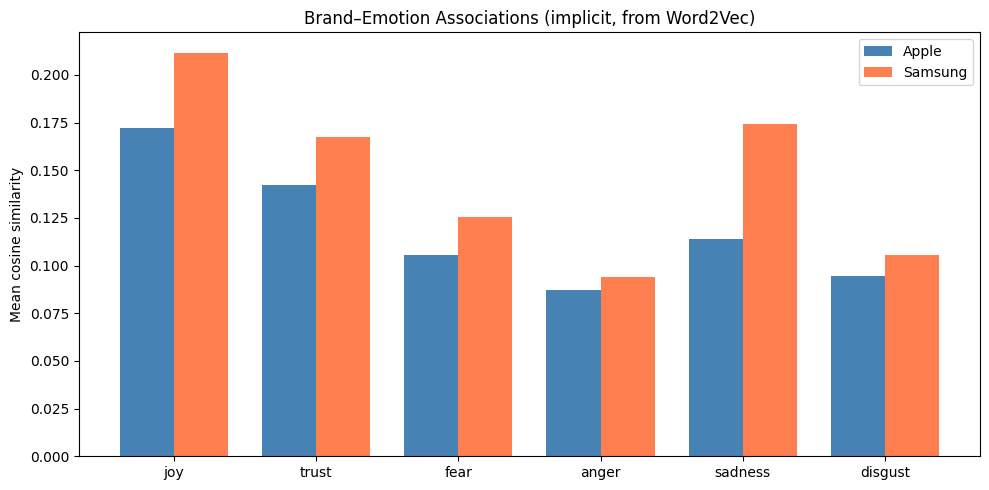

In [35]:
# Grouped bar chart: Apple vs Samsung across emotions
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(emotion_df))
width = 0.38

ax.bar(x - width/2, emotion_df['apple'],   width, label='Apple',   color='steelblue')
ax.bar(x + width/2, emotion_df['samsung'], width, label='Samsung', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(emotion_df['emotion'])
ax.set_ylabel('Mean cosine similarity')
ax.set_title('Brand–Emotion Associations (implicit, from Word2Vec)')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()

   emotion  apple_share  samsung_share  share_gap
0      joy       0.2407         0.2408    -0.0001
1    trust       0.1988         0.1905     0.0083
2     fear       0.1473         0.1429     0.0044
3    anger       0.1218         0.1072     0.0146
4  sadness       0.1594         0.1983    -0.0390
5  disgust       0.1321         0.1203     0.0118


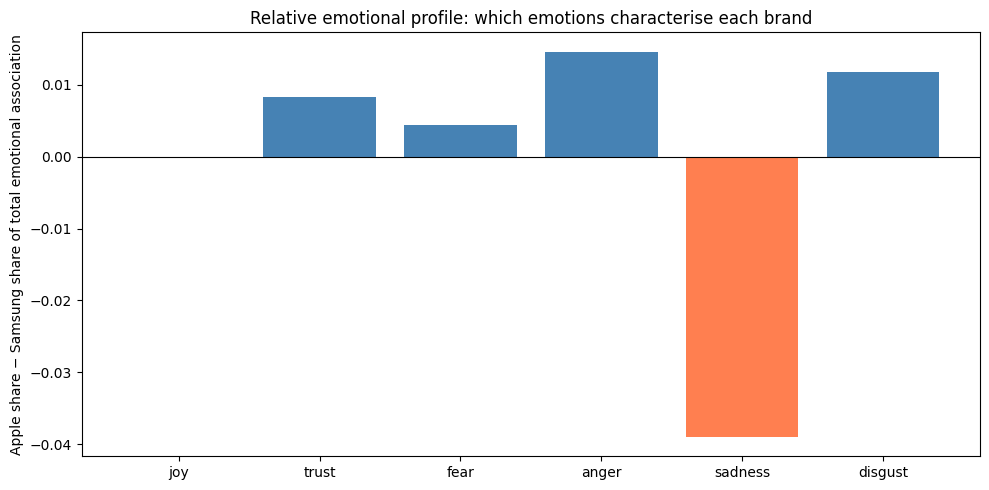

In [36]:
# Normalised emotion profile: what FRACTION of each brand's total emotional
# association is taken up by each emotion? This removes the baseline difference
# in overall emotional engagement and reveals the *shape* of each brand's
# emotional profile.
apple_total   = emotion_df['apple'].sum()
samsung_total = emotion_df['samsung'].sum()

emotion_df['apple_share']   = emotion_df['apple']   / apple_total
emotion_df['samsung_share'] = emotion_df['samsung'] / samsung_total
emotion_df['share_gap']     = emotion_df['apple_share'] - emotion_df['samsung_share']

print(emotion_df[['emotion', 'apple_share', 'samsung_share', 'share_gap']].round(4))

# Plot the share gap
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if g > 0 else 'coral' for g in emotion_df['share_gap']]
ax.bar(emotion_df['emotion'], emotion_df['share_gap'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Apple share − Samsung share of total emotional association')
ax.set_title('Relative emotional profile: which emotions characterise each brand')
plt.tight_layout()
plt.show()

**Conclusion : Discrete Emotion Analysis**

- **Raw similarities (first chart):** Samsung is more strongly associated with *every* emotion category than Apple: both positive and negative. This is not a valence finding. It reflects that Samsung-related words sit in more emotionally charged review contexts overall, while Apple-related words sit in more transactional/descriptive contexts.
- To recover each brand's *emotional profile* independent of this baseline difference, each emotion's similarity is normalized by the brand's total emotional association, producing each emotion's *share* of the brand's emotional footprint.
- **The normalised profile reveals that the Apple-Samsung gap is concentrated in a single emotion: sadness** (Apple share = 15.9%, Samsung share = 19.8%; gap ≈ -0.04). Samsung is disproportionately associated with the language of disappointment and regret (`sad`, `disappointed`, `unhappy`, `regret`, `sorry`, `upset`).
- Joy is essentially tied (gap ≈ 0). All other emotions show small Apple-leaning gaps of around 1 percentage point.

#### **5. Discussion and Interpretation**

| Measure | Result | Direction |
|---|---|---|
| Explicit (star ratings) | Samsung 3.97 vs Apple 3.92 | Samsung marginally higher |
| Implicit valence (WEAT) | Cohen's d = 0.45 | Apple more positive |
| Discrete emotion (share-normalised) | Sadness gap ≈ −0.04 | Samsung carries more regret language |

##### Answering the Research Question

> *Do consumers hold different implicit versus explicit attitudes toward Apple and Samsung, and what emotional associations drive the gap between these two levels of evaluation?*

**Yes, they do.** Star ratings and the implicit valence measure point in opposite directions: Samsung has slightly higher ratings, but Apple has a stronger positive association in the embedding space. This gap is not spread evenly across emotions. It shows up almost entirely in **words related to sadness** (disappointment, regret), where Samsung appears more often than Apple. So the implicit advantage Apple has is not because people love it more, but because people express less regret about buying it. This pattern fits with all three theories used in this project: dual-process theory, brand-schema theory, and cognitive dissonance.

##### Limitations:

1. **Small word sets reduce statistical power.** Because each brand only has 4 target words, the permutation test can only produce a limited number of unique reshuffles (70 in total). This means the test cannot give a strongly significant p-value even when a real effect exists. The effect size is therefore a more useful number to look at than the p-value.
2. **Apple and Samsung have different vocabulary sizes.** Apple appears in the corpus with more related words (mac, ipad, siri, etc.) than Samsung does, even though this project focuses only on phones. This made it necessary to trim the Apple list to keep both sides balanced, but the bigger Apple vocabulary is itself an interesting finding about brand schema.
3. **The findings reflect Amazon reviews only.** The patterns observed here come from how people write Amazon product reviews. Other platforms like Twitter, YouTube comments, or forums might show different emotional patterns for the same brands.
4. **The effect sizes are small.** The emotion-share differences are all 4 percentage points or less. This means the findings should be read as directional patterns rather than strong, definitive conclusions. To make stronger claims, the analysis would need to be repeated on a larger dataset or using pre-trained word embeddings.